# Week 4, Day 1
## Problem Framing, Hold-Out Test & Baseline (UCI Adult / Census Income)

1. Frame the business problem and pick a metric
2. Load and explore the data
3. Build a proper train/hold-out split (so we can trust our final numbers)
4. Build two "baseline" models: dumb-but-honest yardsticks
5. Look at where the baseline gets things wrong


## Task 1: Problem Definition & Success Metric

**Business framing.** Imagine we work for a company selling a premium financial product
(e.g. investment services). We want to target outreach (calls, mailers) at people likely
to earn >$50K/year, because outreach costs money (staff time, printing, calls) and we
don't want to waste it on people unlikely to convert.

- **Target / positive class:** `income = >50K` -> encoded as `1`. Everyone else (`<=50K`) -> `0`.
- **Business objective:** maximize precision among the people we contact i.e. when we
  decide to reach out to someone, we want to be right as often as possible. We're willing to
  miss some high-earners (lower recall) rather than waste outreach budget on people who
  don't qualify.
- **Why precision over recall here:** Recall matters more when missing a positive is very
  costly (e.g. cancer screening - you don't want to miss a sick patient). Precision matters
  more when acting on a false positive is expensive like mailing/calling someone who isn't
  actually a good target burns real money and can annoy the customer. Since outreach has a
  hard dollar cost per contact, we lean toward **precision**, while still tracking ROC AUC
  as an overall discrimination metric that doesn't depend on a specific threshold.
- **Primary metric for this project:** **F1-score at a sensible default threshold**, with
  **ROC AUC** reported as a secondary, threshold-independent measure of overall model
  quality. F1 is a good single number because it balances precision and recall rather than
  letting us cheat by picking a trivial extreme (e.g. 100% recall by contacting everyone).


In [79]:
%pip install numpy pandas matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42   # fixed seed -> same split every time we re-run this notebook
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


## Task 2: Data Load & Quick EDA


**Missing values:** this dataset marks missing entries with the string `'?'` instead of a
proper NaN. We convert those to real NaN so pandas/sklearn treat them as missing (and so
`.isna()` actually finds them).


In [81]:
# Column names, per the official UCI documentation for this dataset
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)

print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [82]:
# Converts he target to binary 0/1.
# income comes in as '<=50K' or '>50K' (sometimes with a trailing period in some mirrors)
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()


,income,target
0,<=50K,0
7,>50K,1


In [83]:
# Column types and missingness
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print()
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size:.2%} of all cells)")


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
target            int64
dtype: object

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total missing cells: 6465 (0.83% of all cells)


In [84]:
# Numeric summaries
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [85]:
# Value counts for a few key categorical columns
for col in ["workclass", "education", "marital-status", "occupation", "sex", "race"]:
    print(f" --- {col} ")
    print(df[col].value_counts(dropna=False).head(8))
    print()


 --- workclass 
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Name: count, dtype: int64

 --- education 
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64

 --- marital-status 
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 --- occupation 
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                 

In [86]:
# Class base rate -- how many people actually earn >50K?
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


This base rate matters a lot: it's our "do-nothing" reference point. If ~24% of people
earn >50K, then a model that *always* guesses "<=50K" is already approximately 76% accurate which is
why accuracy alone is a misleading metric for this problem (more on this in Task 4). 


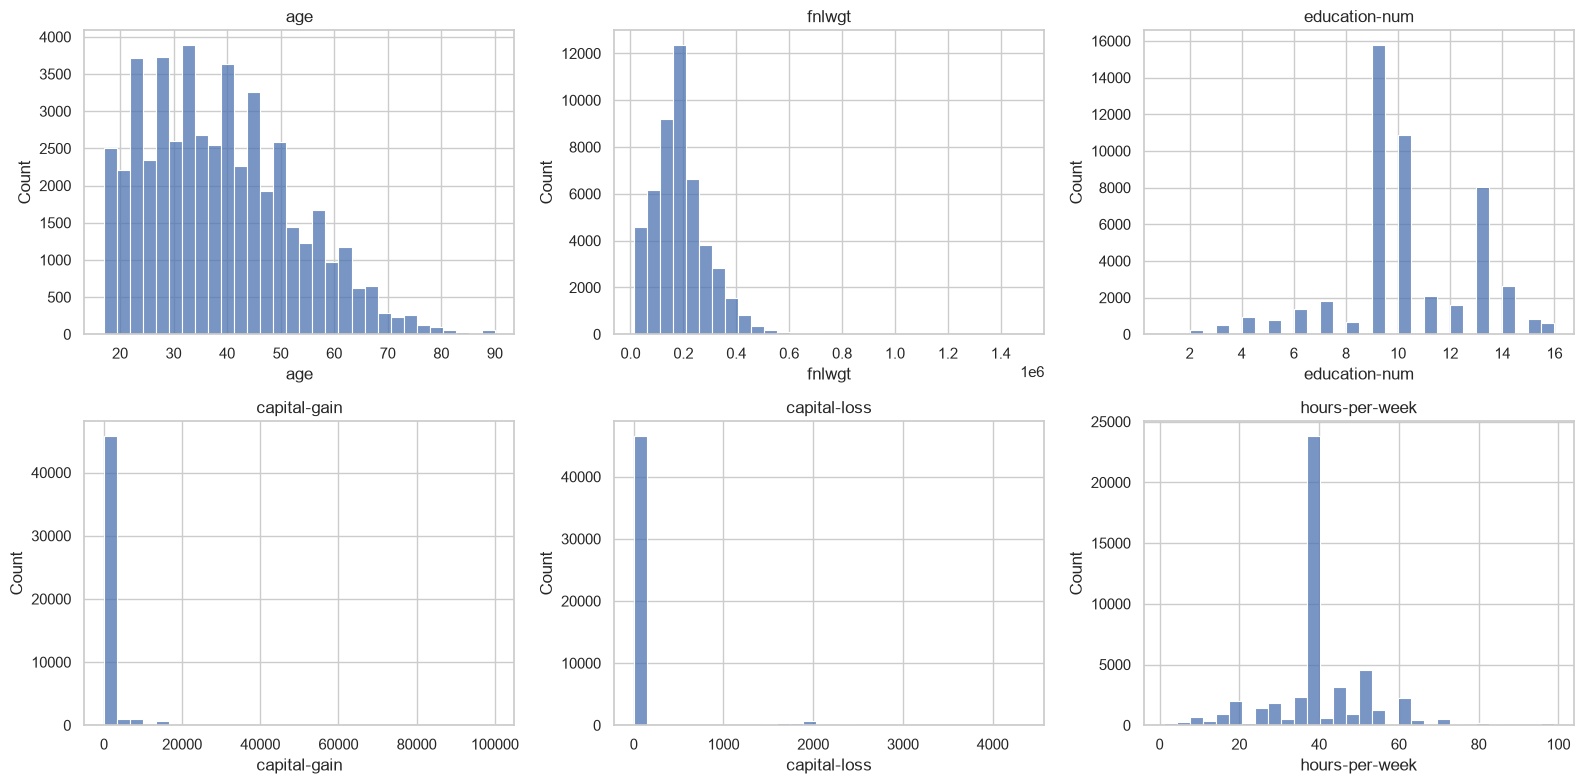

In [87]:
# Visualizations: histograms for numeric features + bar plots for categoricals
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("charts/eda_numeric_histograms.png", dpi=120)
plt.show()


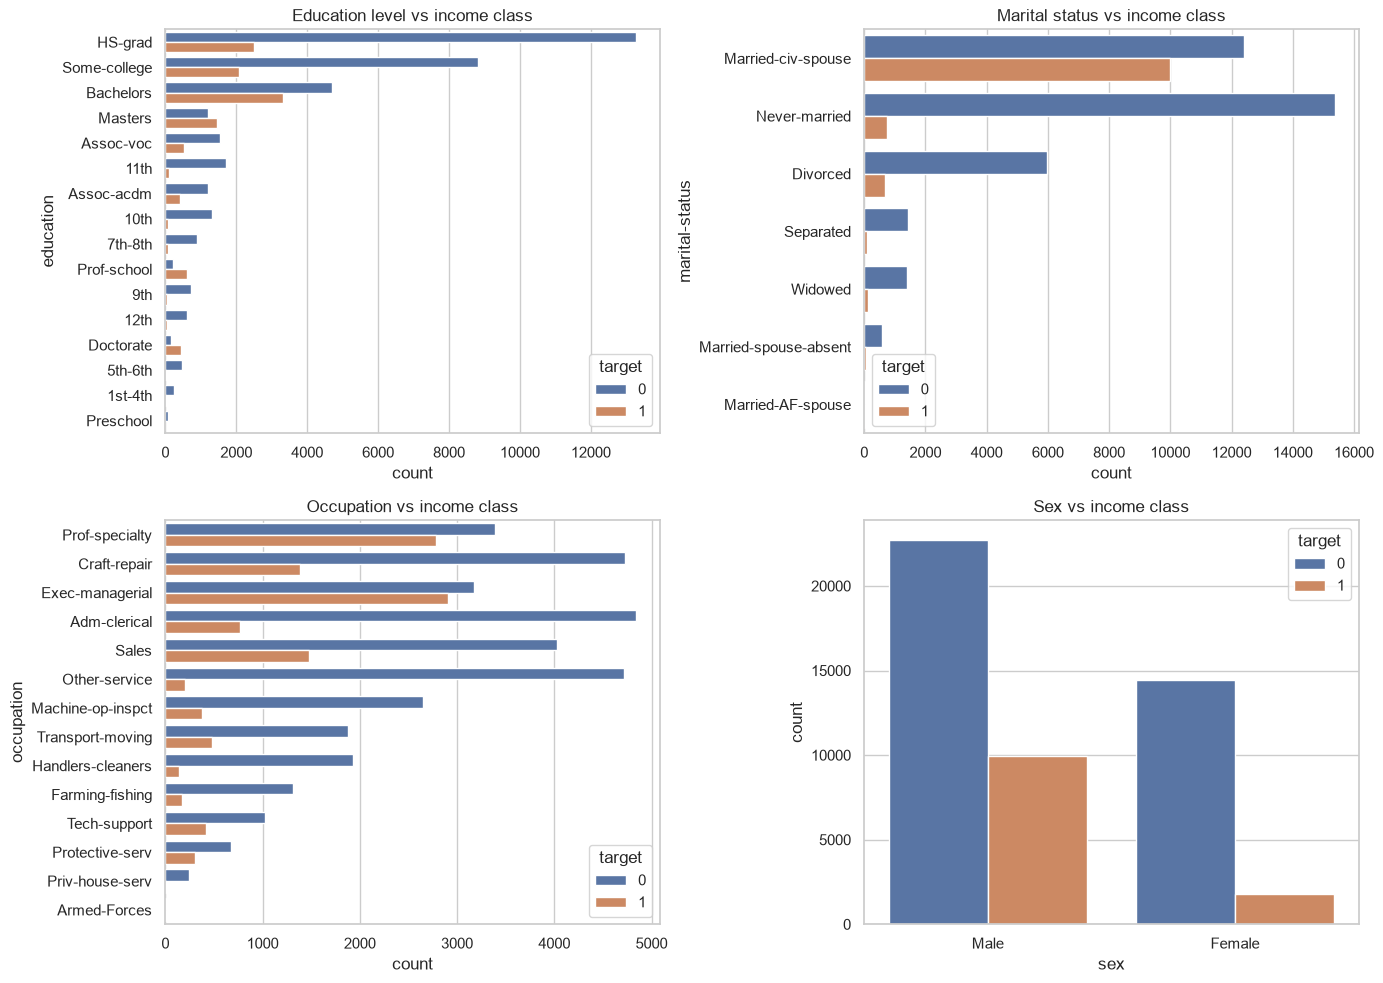

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, y="education", order=df["education"].value_counts().index,
              hue="target", ax=axes[0, 0])
axes[0, 0].set_title("Education level vs income class")

sns.countplot(data=df, y="marital-status", order=df["marital-status"].value_counts().index,
              hue="target", ax=axes[0, 1])
axes[0, 1].set_title("Marital status vs income class")

sns.countplot(data=df, y="occupation", order=df["occupation"].value_counts().index,
              hue="target", ax=axes[1, 0])
axes[1, 0].set_title("Occupation vs income class")

sns.countplot(data=df, x="sex", hue="target", ax=axes[1, 1])
axes[1, 1].set_title("Sex vs income class")

plt.tight_layout()
plt.savefig("charts/eda_categorical_bars.png", dpi=120)
plt.show()


In [89]:
# Summary table: class counts + a few notable feature distributions, saved for the report
summary_rows = []
summary_rows.append({"metric": "Total rows", "value": len(df)})
summary_rows.append({"metric": "Positive class count (>50K)", "value": int((df.target == 1).sum())})
summary_rows.append({"metric": "Negative class count (<=50K)", "value": int((df.target == 0).sum())})
summary_rows.append({"metric": "Base rate (% positive)", "value": f"{base_rate:.2%}"})
summary_rows.append({"metric": "Mean age", "value": round(df['age'].mean(), 1)})
summary_rows.append({"metric": "Mean hours-per-week", "value": round(df['hours-per-week'].mean(), 1)})
summary_rows.append({"metric": "% with capital-gain > 0", "value": f"{(df['capital-gain'] > 0).mean():.2%}"})
summary_rows.append({"metric": "% Bachelors or higher (approx, by education-num>=13)",
                      "value": f"{(df['education-num'] >= 13).mean():.2%}"})
summary_rows.append({"metric": "Missing 'workclass'", "value": int(df['workclass'].isna().sum())})
summary_rows.append({"metric": "Missing 'occupation'", "value": int(df['occupation'].isna().sum())})
summary_rows.append({"metric": "Missing 'native-country'", "value": int(df['native-country'].isna().sum())})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("charts/eda_summary_table.csv", index=False)
summary_df


,metric,value
0,Total rows,48842
1,Positive class count (>50K),11687
2,Negative class count (<=50K),37155
3,Base rate (% positive),23.93%
4,Mean age,38.6
5,Mean hours-per-week,40.4
6,% with capital-gain > 0,8.26%
7,"% Bachelors or higher (approx, by education-nu...",24.79%
8,Missing 'workclass',2799
9,Missing 'occupation',2809


## Task 3: Create Reproducible Splits

**Why a hold-out test set at all?** If we tune our model and pick our final approach by
repeatedly checking performance on the *same* data we'll report our final number on, we're
effectively "peeking at the answer key" we will unconsciously choose whatever settings
happen to work best on that particular data, which **overstates** how well the model will do
on genuinely new people. This is called **data leakage / overfitting to the test set**.

**The fix:** split off a hold-out test set right now, before any modeling, and don't look
at it again until the very end when we report final numbers. Everything else (EDA, baseline
tuning, feature engineering, model comparison) happens only on the training/dev data.

- We use `stratify=target` so the hold-out set has the same ~24%/76% class balance as the
  full dataset otherwise a random split could accidentally end up with too few positive
  examples to evaluate reliably.
- We fix `random_state=42` so that every time this notebook is re-run, we get the *exact
  same* split


In [90]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

# Optional further split: carve a dev set out of the remaining 80%
# (10% of the ORIGINAL data -> 12.5% of train_dev_df, since train_dev_df is 80% of total)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df):.1%} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df):.1%} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df):.1%} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean():.2%}")


Train size: 34188  (70.0% of full data)
Dev size:   4885   (10.0% of full data)
Test size:  9769  (20.0% of full data)

Class balance check (share of positives in each split):
  Full data         : 23.93%
  Train             : 23.93%
  Dev               : 23.93%
  Test (hold-out)   : 23.93%


**Why this matters:** A hold-out test set gives us an
honest, one-time estimate of how the model will perform on people it has never seen
which is the real-world use case. If we use the test set during hyperparameter tuning (e.g.
picking the best `max_depth` by checking test accuracy), we end up implicitly fitting the
model to the test set's quirks, so our reported performance becomes optimistic and won't
hold up in production. That's why we tune using the **train/dev** split and touch the
**test** set only once, at the very end, for final reporting.


## Task 4 Implement Simple Baselines

Before building anything fancy, we build baselines: deliberately simple models that
tell us the minimum bar any real model must clear to be worth using. If a complex model
can't beat these, it's not adding value.

**Baseline 1: Majority-class predictor.** Always predicts the most common class (`<=50K`).
This tells us what "doing nothing clever" looks like.

**Baseline 2: Single-feature rule.** We'll use **`education-num >= 13`** (13 = Bachelor's
degree or higher in this dataset's encoding) OR **`capital-gain > 0`** as a simple
"predict >50K" rule. *Justification:* both education level and capital gains are strongly,
intuitively tied to income since more education tends to mean higher-paying work, and having
any capital gains at all usually implies enough wealth to invest. This gives us a baseline
that's simple but not naive.


In [91]:
# Baseline 1: Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
# "Probability" for a constant predictor -- use the class itself as a degenerate score
y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [92]:
# Baseline 2: Single-feature rule
# Rule: predict >50K if education-num >= 13 OR capital-gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
# A simple continuous "score" version for ROC/PR AUC: combine both signals into one number
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [93]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df.to_csv("charts/baseline_metrics.csv")
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7452,0.4746,0.6031,0.5312,0.7426,0.4946


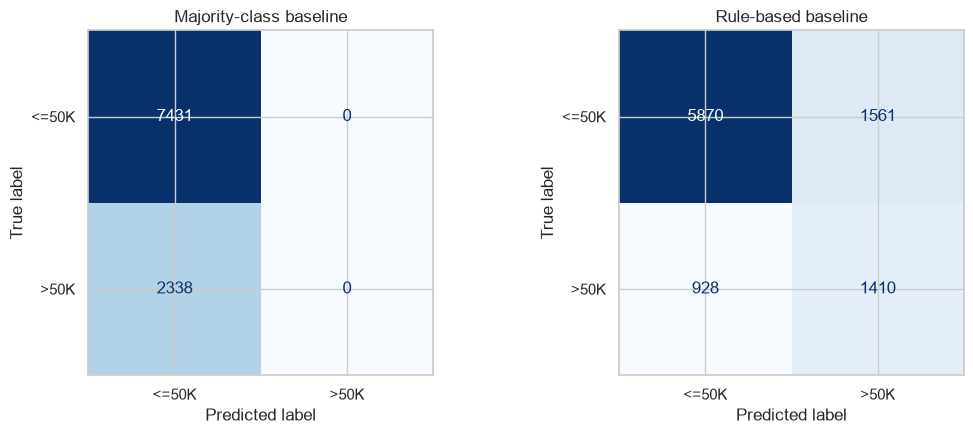

In [94]:
# Confusion matrices for both baselines
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_majority = confusion_matrix(y_test, y_pred_majority)
ConfusionMatrixDisplay(cm_majority, display_labels=["<=50K", ">50K"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Majority-class baseline")

cm_rule = confusion_matrix(y_test, y_pred_rule)
ConfusionMatrixDisplay(cm_rule, display_labels=["<=50K", ">50K"]).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Rule-based baseline")

plt.tight_layout()
plt.savefig("charts/baseline_confusion_matrices.png", dpi=120)
plt.show()


**Interpretation.** The majority-class baseline gets decent *accuracy* (roughly the
~76% base rate) but has **zero precision and zero recall** on the positive class it never
predicts `>50K` at all, so it's useless for our actual business goal of finding high earners,
despite looking "accurate." The rule-based baseline trades some accuracy for a real ability
to catch positives: it has non-zero precision and recall and a meaningfully higher ROC
AUC/PR AUC, because it's actually using signal in the data instead of a constant guess. **The
rule-based baseline wins** on every metric that matters for our objective (F1, precision,
recall, ROC AUC), even if the majority-class baseline can look competitive on raw accuracy 
which is exactly why we didn't pick accuracy as our primary metric in Task 1. For a real
model to be considered useful this week, it should beat the rule-based baseline's F1 by a
clear, non-trivial margin (a common rule of thumb is at least +0.05–0.10 F1, not just a
fraction of a percentage point), and should improve ROC AUC as well, otherwise the added
complexity isn't earning its keep.


## Task 5: Initial Error Analysis & Next Steps

Now we look at specific mistakes the rule-based baseline makes, to understand patterns
worth fixing before we build real models tomorrow. We'll sample false positives (predicted
`>50K` but actually `<=50K`) and false negatives (predicted `<=50K` but actually `>50K`).


In [95]:
test_analysis = test_df.copy()
test_analysis["pred"] = y_pred_rule
test_analysis["true"] = y_test

false_positives = test_analysis[(test_analysis["pred"] == 1) & (test_analysis["true"] == 0)]
false_negatives = test_analysis[(test_analysis["pred"] == 0) & (test_analysis["true"] == 1)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

cols_to_show = ["age", "workclass", "education", "education-num", "marital-status",
                 "occupation", "capital-gain", "capital-loss", "hours-per-week", "sex", "income"]

print("\nSample false positives (predicted >50K, actually <=50K):")
display(false_positives[cols_to_show].sample(12, random_state=RANDOM_STATE))


False positives: 1561
False negatives: 928

Sample false positives (predicted >50K, actually <=50K):


,age,workclass,education,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,sex,income
23717,41,State-gov,Bachelors,13,Never-married,Prof-specialty,0,0,40,Male,<=50K
22892,24,Self-emp-inc,Bachelors,13,Never-married,Exec-managerial,0,0,40,Male,<=50K
42409,37,Self-emp-not-inc,Bachelors,13,Separated,Transport-moving,0,0,50,Male,<=50K
22958,18,Self-emp-not-inc,11th,7,Never-married,Other-service,594,0,4,Female,<=50K
1438,41,Self-emp-not-inc,Masters,14,Divorced,Prof-specialty,0,0,35,Female,<=50K
25256,58,Private,Bachelors,13,Widowed,Exec-managerial,0,0,40,Female,<=50K
35392,27,Private,Masters,14,Never-married,Prof-specialty,0,0,45,Male,<=50K
27647,35,Private,Bachelors,13,Never-married,Sales,0,1590,40,Male,<=50K
20635,46,Private,Bachelors,13,Divorced,Prof-specialty,0,0,40,Male,<=50K
33001,32,Private,HS-grad,9,Married-civ-spouse,Adm-clerical,2580,0,40,Male,<=50K


In [96]:
print("Sample false negatives (predicted <=50K, actually >50K):")
display(false_negatives[cols_to_show].sample(12, random_state=RANDOM_STATE))


Sample false negatives (predicted <=50K, actually >50K):


,age,workclass,education,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,sex,income
45369,67,Private,11th,7,Married-civ-spouse,Other-service,0,0,9,Male,>50K
15296,54,Self-emp-not-inc,Assoc-acdm,12,Married-civ-spouse,Sales,0,0,50,Male,>50K
17404,38,Self-emp-not-inc,10th,6,Married-civ-spouse,Sales,0,1887,40,Male,>50K
28453,38,Private,Assoc-voc,11,Married-civ-spouse,Tech-support,0,0,36,Female,>50K
44586,51,Private,Some-college,10,Married-civ-spouse,Craft-repair,0,0,48,Male,>50K
18149,36,Private,HS-grad,9,Married-civ-spouse,Craft-repair,0,1887,60,Male,>50K
44641,25,Private,Assoc-voc,11,Married-civ-spouse,Craft-repair,0,0,40,Male,>50K
30215,50,Federal-gov,Some-college,10,Married-civ-spouse,Exec-managerial,0,0,40,Male,>50K
40422,48,Private,HS-grad,9,Married-civ-spouse,Craft-repair,0,0,40,Male,>50K
1395,42,Private,10th,6,Never-married,Transport-moving,0,0,40,Male,>50K


In [97]:
# A little pattern-checking to back up our observations with numbers
print("False negatives -- summary stats (people we wrongly predicted as low earners):")
print(false_negatives[["age", "hours-per-week", "education-num"]].describe().loc[["mean", "50%"]])
print()
print("False positives -- summary stats (people we wrongly predicted as high earners):")
print(false_positives[["age", "hours-per-week", "education-num"]].describe().loc[["mean", "50%"]])
print()
print("False negatives by marital status (top 5):")
print(false_negatives["marital-status"].value_counts().head(5))


False negatives -- summary stats (people we wrongly predicted as low earners):
            age  hours-per-week  education-num
mean  44.044181       44.492457       9.461207
50%   43.000000       40.000000       9.000000

False positives -- summary stats (people we wrongly predicted as high earners):
            age  hours-per-week  education-num
mean  38.742473        40.02114      12.627803
50%   36.000000        40.00000      13.000000

False negatives by marital status (top 5):
marital-status
Married-civ-spouse    849
Divorced               35
Never-married          25
Widowed                 9
Separated               6
Name: count, dtype: int64


**Patterns observed:**
- Many **false negatives** are people with high `hours-per-week` and reasonable
  `education-num` but no`capital-gain` and not "Bachelors-or-higher" (e.g. some-college
  or associate-degree holders, or skilled tradespeople) so our rule misses income signal that
  isn't captured by education or capital gains alone (e.g. occupation type, hours worked,
  age/experience).
- Many false negatives are also concentrated among **married individuals** in specific
  occupations (e.g. exec-managerial, prof-specialty) - `marital-status` and `occupation` look
  like they carry real predictive signal our simple rule ignores entirely.
- **False positives** tend to include younger, highly-educated people (e.g. recent
  Bachelor's/Master's graduates) who haven't yet reached >50K earnings which means that education alone
  overstates income for people early in their career.
- A visible slice of false positives/negatives sit in rows with **missing `workclass` or
  `occupation`** but our current rule doesn't use those columns, but a stronger model will need
  a sane strategy (e.g. an explicit "Missing" category) for those NaNs rather than dropping rows.

**Data/feature issues to fix tomorrow:**
1. **Missing categories**: `workclass`, `occupation`, `native-country` have NaNs (from `'?'`)
   that need explicit handling (e.g. an `"Unknown"` category) rather than silent drops.
2. **Categorical encoding**: columns like `workclass`, `education`, `occupation`,
   `marital-status`, `relationship`, `race`, `sex`, `native-country` need one-hot or target
   encoding for most sklearn models.
3. **`education` vs `education-num` redundancy**: these two columns encode the same
   information twice; keep the numeric version and drop the string version to avoid
   duplicated signal / multicollinearity.
4. **Skewed numerics**: `capital-gain` and `capital-loss` are extremely skewed (mostly 0,
   a few huge values) and may benefit from a log-transform or binarized "has capital gain"
   flag in addition to the raw value.
5. **`fnlwgt` is a census sampling weight**, not a real person-level feature: worth testing
   models with and without it, since it can add noise.
6. **`native-country` has a long tail** of rare categories: consider grouping rare countries
   into an "Other" bucket to avoid overfitting to categories seen only a handful of times.


In [98]:
rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
maj_f1 = results_df.loc["Majority-class", "f1"]
maj_acc = results_df.loc["Majority-class", "accuracy"]
print(rule_f1)
print(rule_auc)
print(maj_f1)
print(maj_acc)



0.5312
0.7426
0.0
0.7607


**Primary metric for the rest of the week.** We will continue optimizing for **F1-score**,
supported by **ROC AUC** as a secondary check. Our rule-based baseline currently sits at
**F1 = 0.5312 / ROC AUC = 0.7426** on the hold-out test set, clearly beating
the majority-class baseline's F1 = 0 (which has zero precision/recall on the
positive class despite 0.7607 accuracy). F1 was chosen because it directly reflects
our business goal -- balancing wasted outreach (false positives, hurting precision) against
missed opportunities (false negatives, hurting recall) -- in a single number that is hard to
game by predicting only one class, unlike accuracy. 